In [33]:
import pandas as pd
from risk_experiment.cogmodels.model_recovery.fit import build_model, load_simulated_data
import os.path as op
import pymc as pm
import arviz as az

from tqdm.contrib.itertools import product
import seaborn as sns

from risk_experiment.utils.data import get_all_behavior
bids_folder = '/data/ds-risk'

In [41]:
real_data = get_all_behavior(bids_folder=bids_folder).droplevel(-1)

100%|██████████| 30/30 [00:01<00:00, 23.37it/s]


In [46]:
models = ['klw', 'eu', 'static_noise', 'static_priors', 'pmrc']

df = []

keys = []
for model, ix in product(models, [1,2]):
    df.append(load_simulated_data(model, ix))
    keys.append((model, ix))

df.append(real_data)
keys.append(('real',1))
df = pd.concat(df, keys=keys, names=['model', 'ix'])

  0%|          | 0/10 [00:00<?, ?it/s]

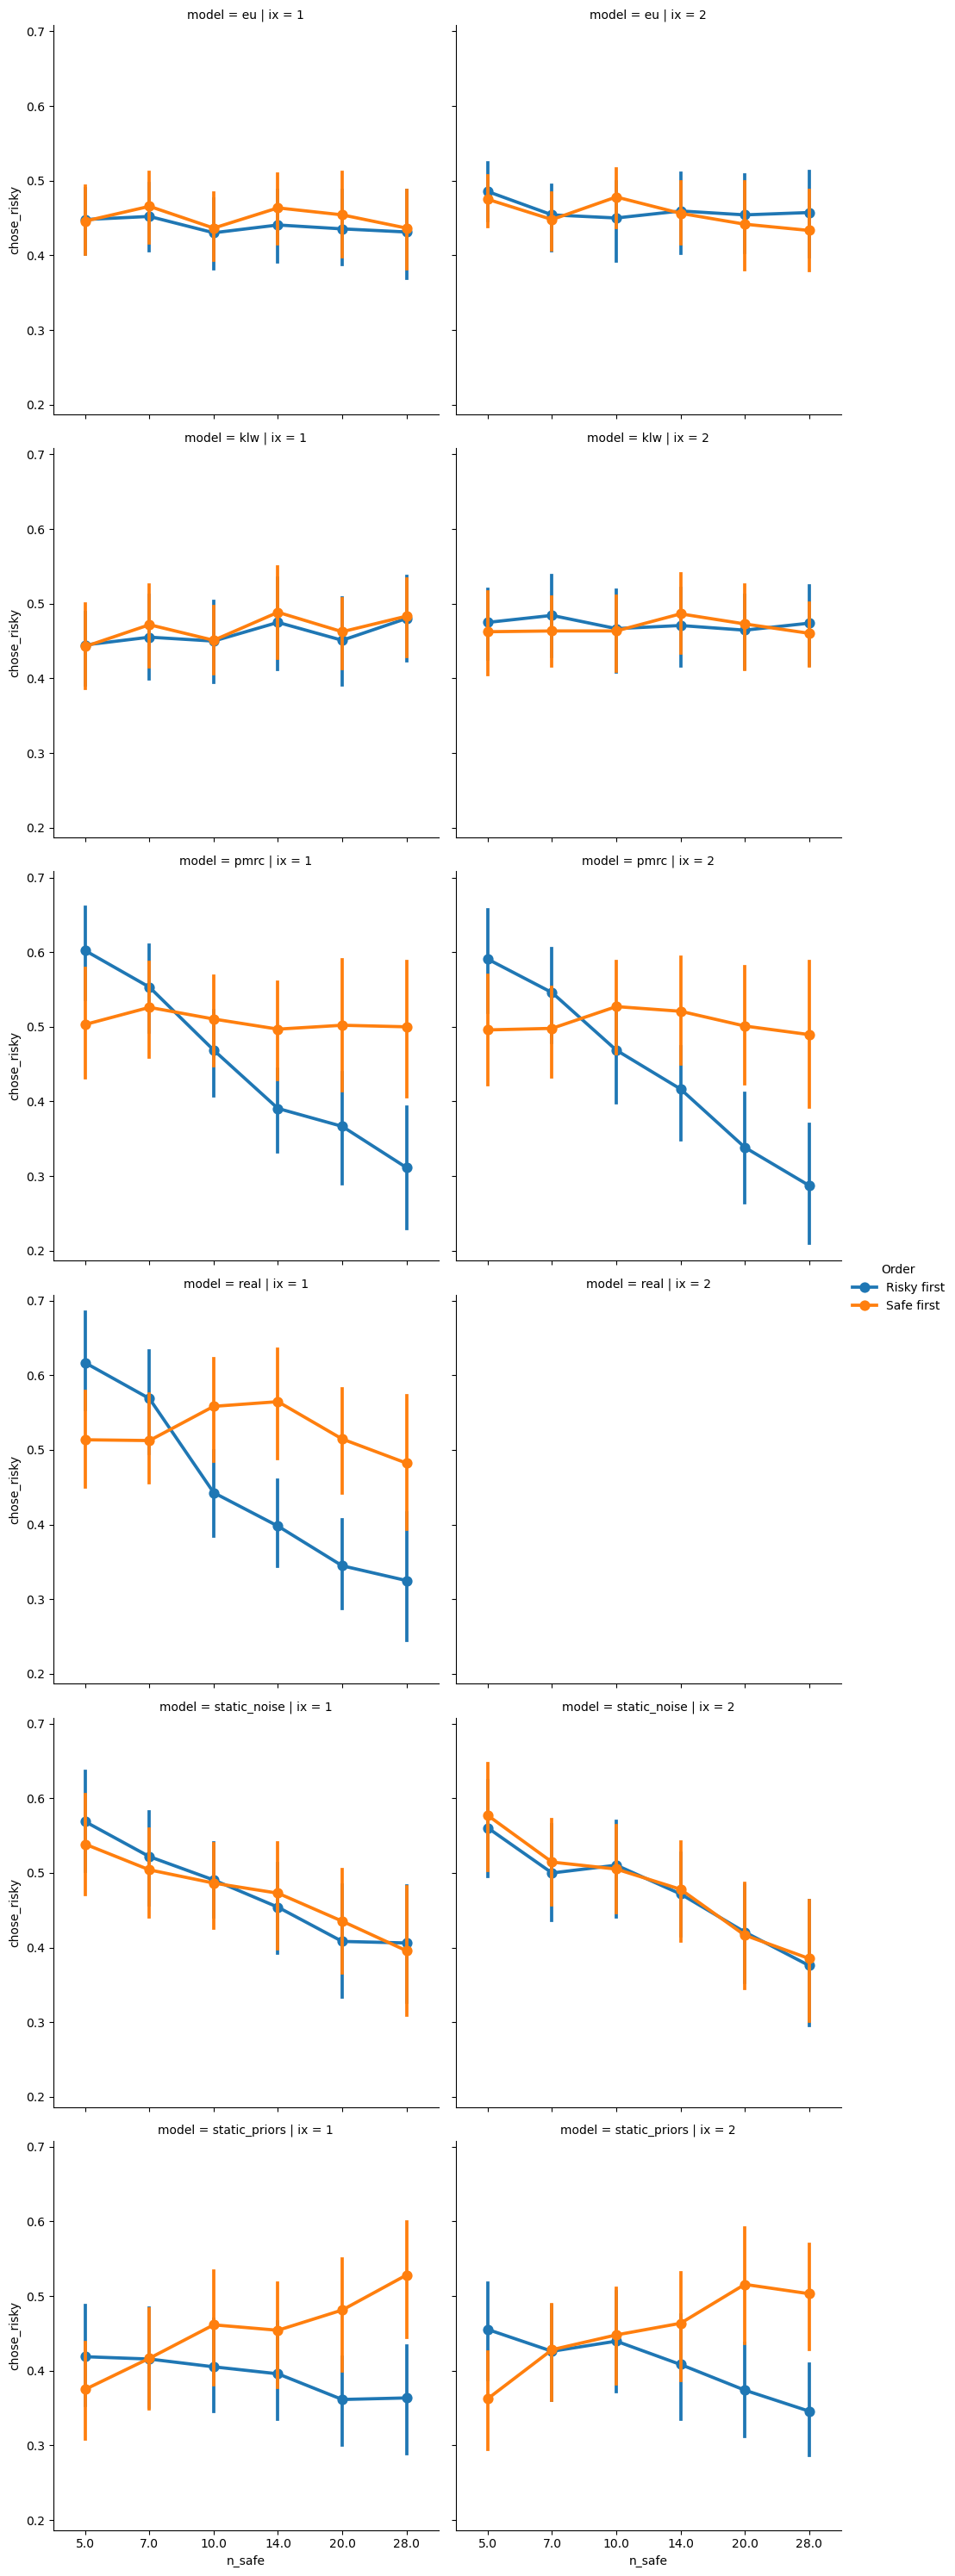

In [47]:
sns.catplot(x='n_safe', y='chose_risky', hue='Order', row='model', col='ix', data=df.groupby(['model', 'ix', 'subject', 'Order', 'n_safe'])[['chose_risky']].mean().reset_index(), kind='point')

In [48]:
import numpy as np
df['n_risky'] = df['n1'].where(df['risky_first'], df['n2'])
df['log(risky/safe)'] = np.log(df['n_risky'] / df['n_safe'])

/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


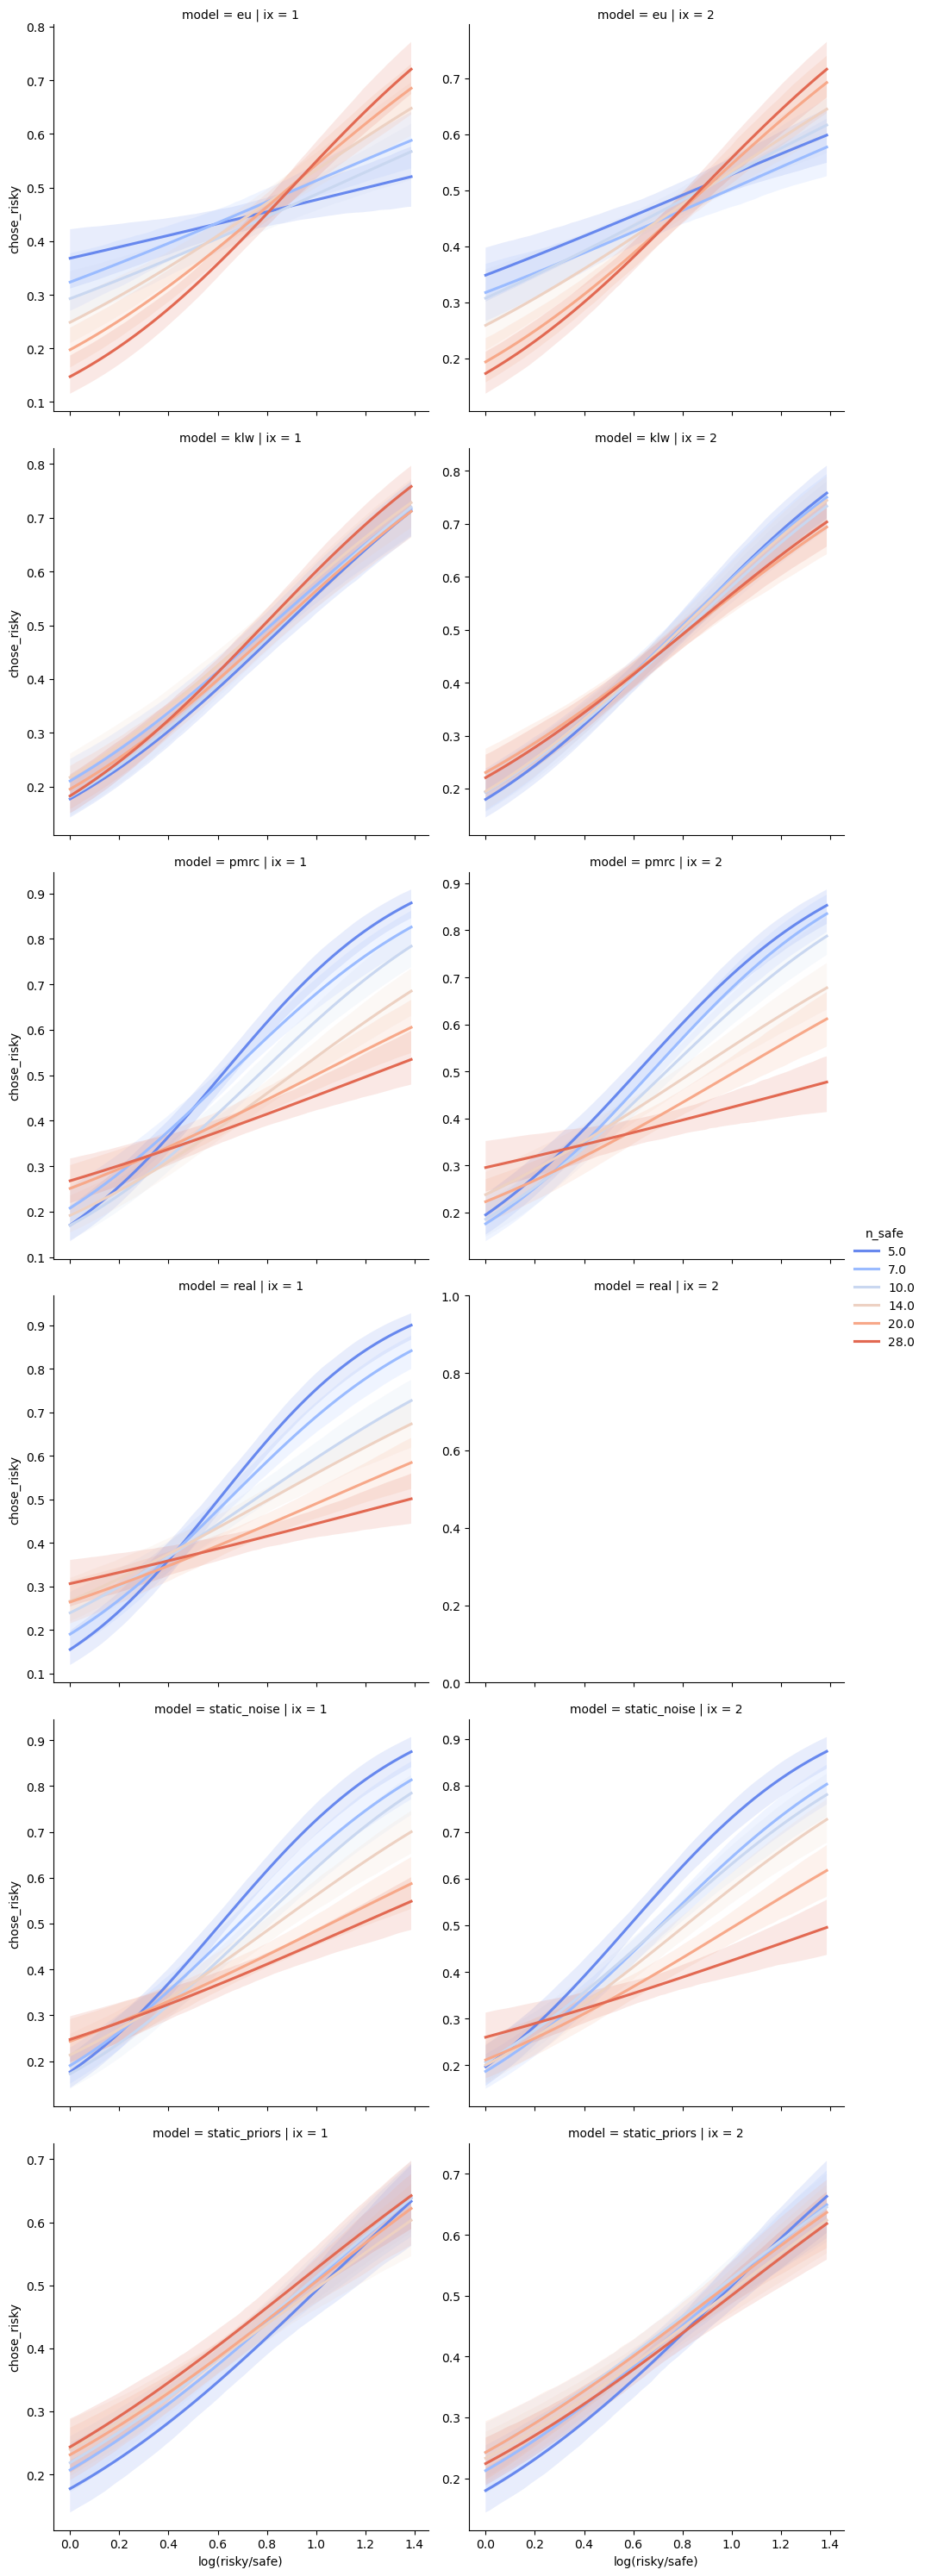

In [50]:
sns.lmplot(x='log(risky/safe)', y='chose_risky', hue='n_safe', row='model', col='ix',
           data=df.groupby(['model', 'ix', 'subject', 'Order', 'n_safe', 'log(risky/safe)'])[['chose_risky']].mean().reset_index(), 
           sharey=False, scatter=False,
           logistic=True, palette='coolwarm')